In [48]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings

warnings.filterwarnings('ignore')

# Завантаження даних
df = pd.read_csv('../data/used_cars2.csv')
print("Початковий розмір датасету:", df.shape)
display(df.head(3))

Початковий розмір датасету: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"


In [49]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [50]:
df.duplicated().sum()


np.int64(0)

In [51]:
df.nunique()


brand             57
model           1898
model_year        34
milage          2818
fuel_type          7
engine          1146
transmission      62
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [52]:
df.describe()


,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [53]:
categorical_columns = ['brand', 'model', 'fuel_type', 'engine', 'transmission',
                       'ext_col', 'int_col', 'accident', 'clean_title']

for col in categorical_columns:
    print(f'Category in {col} is : {df[col].nunique()} unique values')


Category in brand is : 57 unique values
Category in model is : 1898 unique values
Category in fuel_type is : 7 unique values
Category in engine is : 1146 unique values
Category in transmission is : 62 unique values
Category in ext_col is : 319 unique values
Category in int_col is : 156 unique values
Category in accident is : 2 unique values
Category in clean_title is : 1 unique values


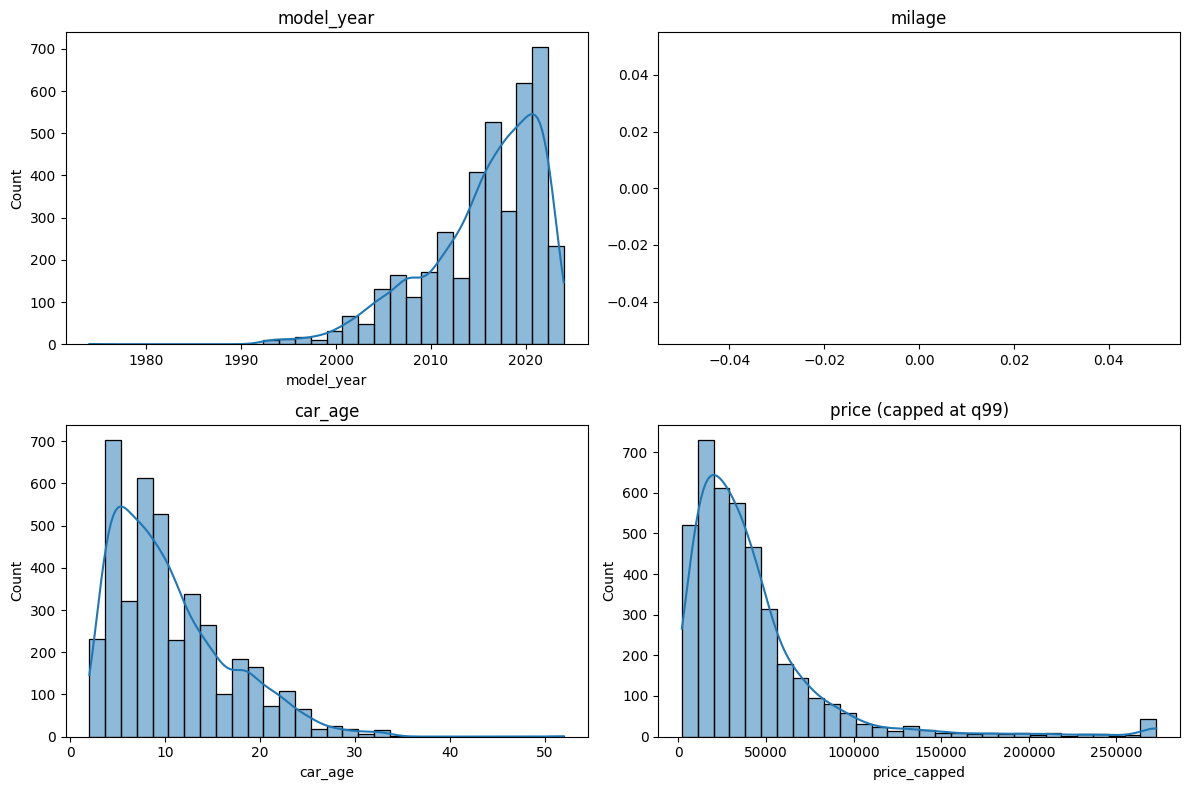

In [54]:
# Distribution of Numerical Features
# Create a visualization-friendly view to reduce outlier compression on charts.
viz_df = df.copy()

if 'price' not in viz_df.columns:
    raise KeyError("Column 'price' is required for this plot.")

# Ensure price is numeric before quantile/capping (handles string/object/arrow string dtypes).
price_numeric = pd.to_numeric(
    viz_df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
 )

# Create car_age on-the-fly for EDA if it is not yet engineered.
if 'car_age' not in viz_df.columns and 'model_year' in viz_df.columns:
    model_year_numeric = pd.to_numeric(viz_df['model_year'], errors='coerce')
    current_year = pd.Timestamp.now().year
    viz_df['car_age'] = (current_year - model_year_numeric).clip(lower=0)

price_cap = price_numeric.quantile(0.99)
viz_df['price_capped'] = price_numeric.clip(upper=price_cap)
viz_df['price_log1p'] = np.log1p(price_numeric)

candidate_features = ['model_year', 'milage', 'car_age', 'price_capped']
numerical_features = [col for col in candidate_features if col in viz_df.columns]

if not numerical_features:
    raise ValueError('No numerical features available for plotting.')

n_features = len(numerical_features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(12, 4 * n_rows))
for i, feature in enumerate(numerical_features, start=1):
    plt.subplot(n_rows, n_cols, i)
    feature_values = pd.to_numeric(viz_df[feature], errors='coerce').dropna()
    sns.histplot(data=feature_values, bins=30, kde=True)
    title = feature if feature != 'price_capped' else 'price (capped at q99)'
    plt.title(title)
plt.tight_layout()
plt.show()


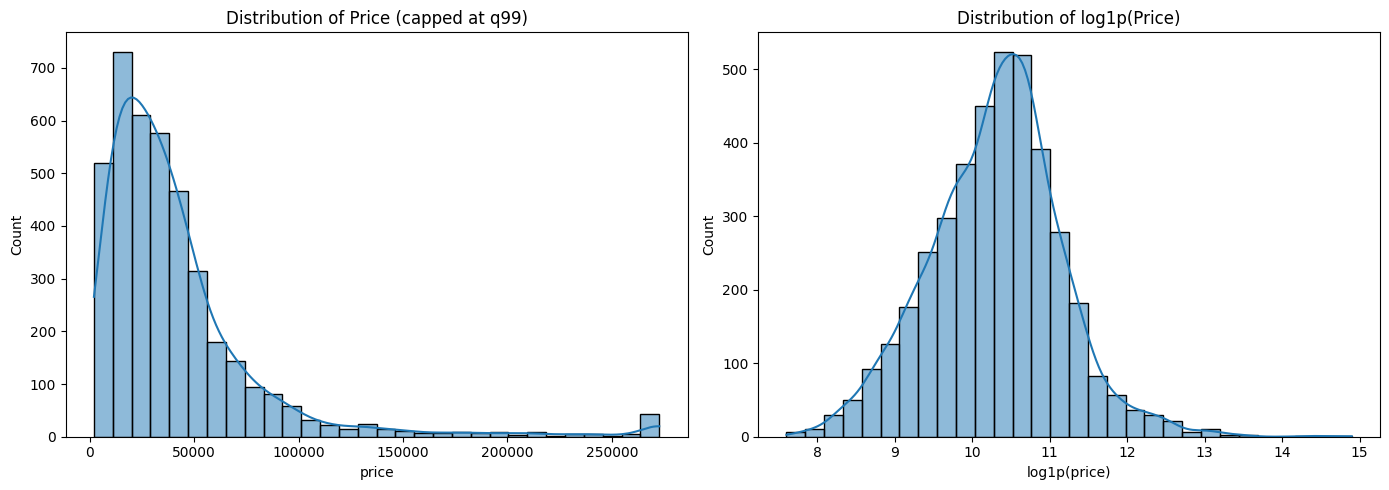

In [55]:
# Price Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=viz_df['price_capped'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price (capped at q99)')
axes[0].set_xlabel('price')

sns.histplot(data=viz_df['price_log1p'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of log1p(Price)')
axes[1].set_xlabel('log1p(price)')

plt.tight_layout()
plt.show()


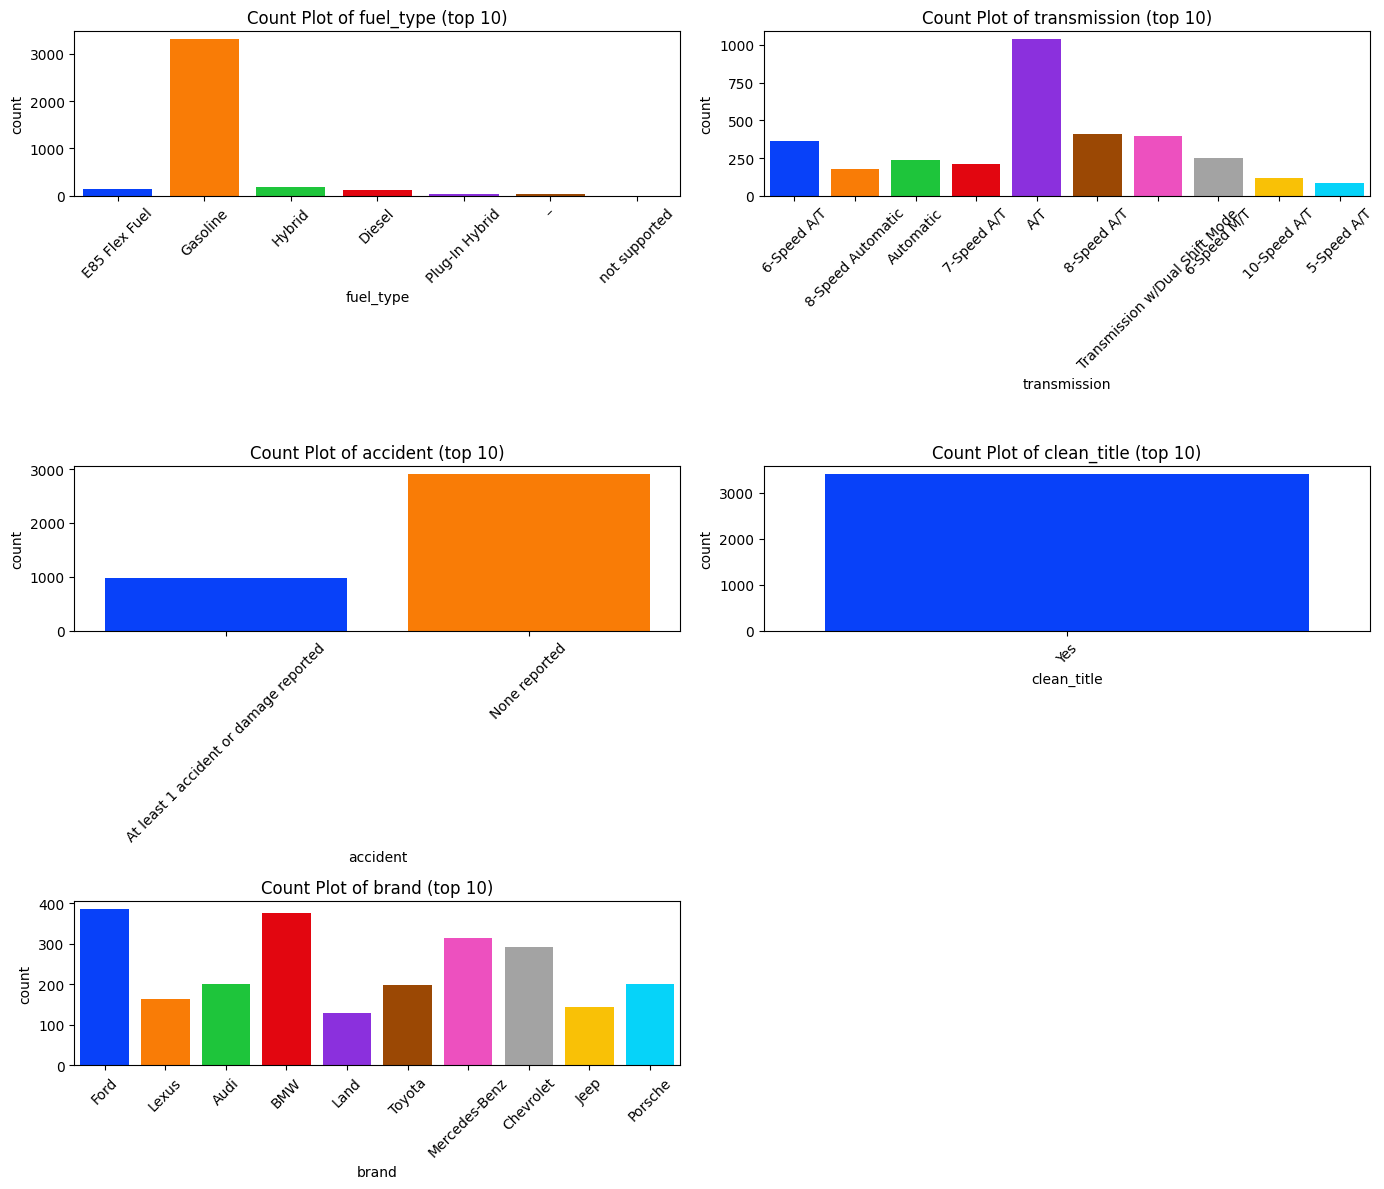

In [56]:
# Define the list of categorical columns to analyze
plot_cats = ['fuel_type', 'transmission', 'accident', 'clean_title', 'brand']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.ravel()

for i, column in enumerate(plot_cats):
    # Keep only top categories to improve readability.
    cleaned = df[column].astype(str).str.strip()
    cleaned = cleaned.replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown', '-': 'Unknown'})
    top_vals = cleaned.value_counts().head(10).index
    sub = cleaned[cleaned.isin(top_vals)]

    sns.countplot(x=sub, palette='bright', ax=axes[i], saturation=0.95)
    axes[i].set_title(f'Count Plot of {column} (top 10)')
    axes[i].set_xlabel(column)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(plot_cats), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


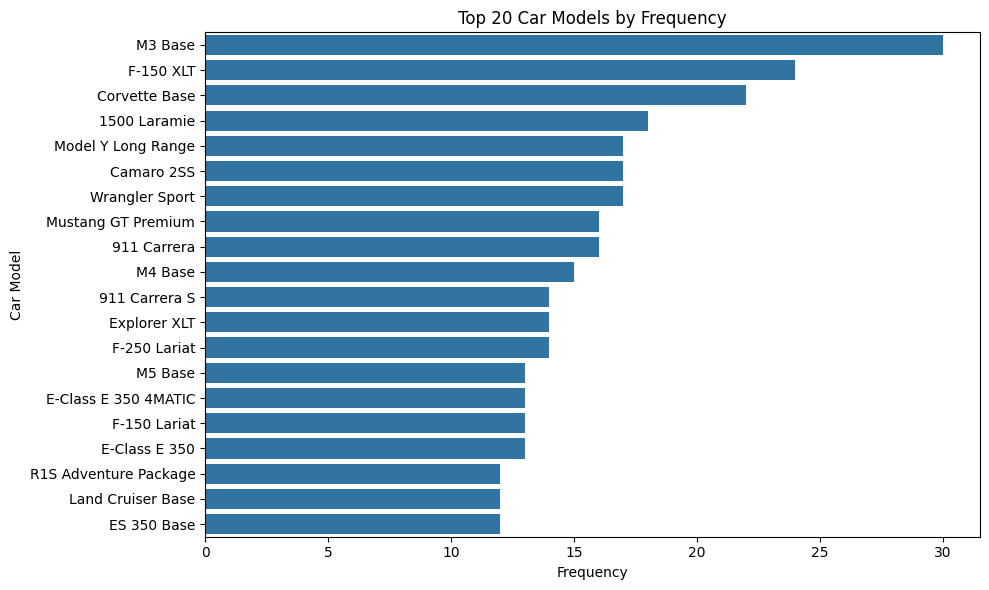

In [57]:
n = 20
top_car_models = df['model'].value_counts().head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()


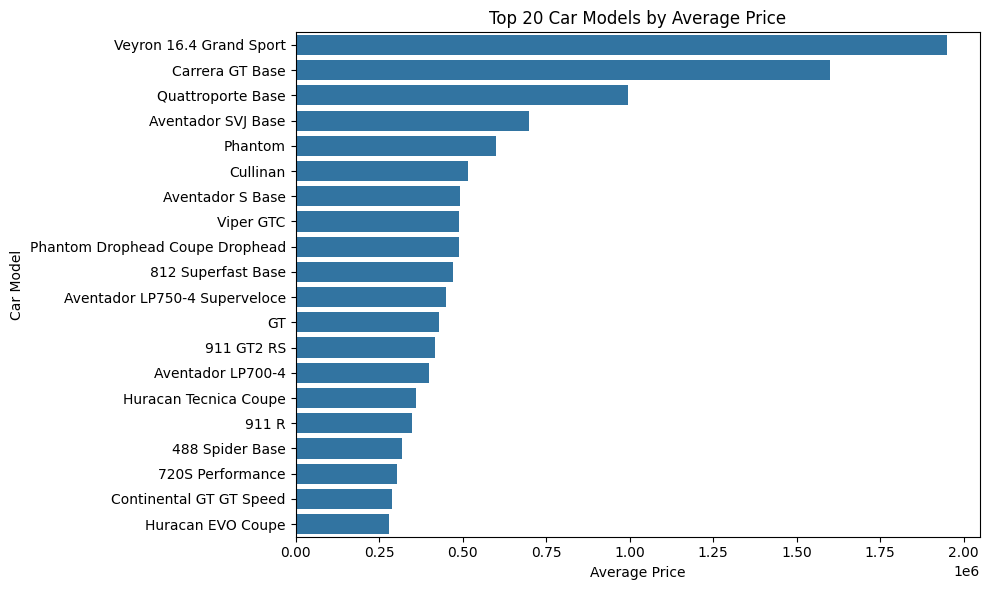

In [58]:
# Calculate average price for each car model (safe for raw string price values)
price_numeric = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
 )

plot_df = pd.DataFrame({
    'model': df['model'].astype(str).str.strip(),
    'price_numeric': price_numeric
}).dropna(subset=['model', 'price_numeric'])

avg_prices_by_car = (
    plot_df.groupby('model')['price_numeric']
    .mean()
    .sort_values(ascending=False)
 )

# Plot top N car models by average price
n = 20
top_car_models = avg_prices_by_car.head(n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_car_models.values, y=top_car_models.index)
plt.title(f'Top {n} Car Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()


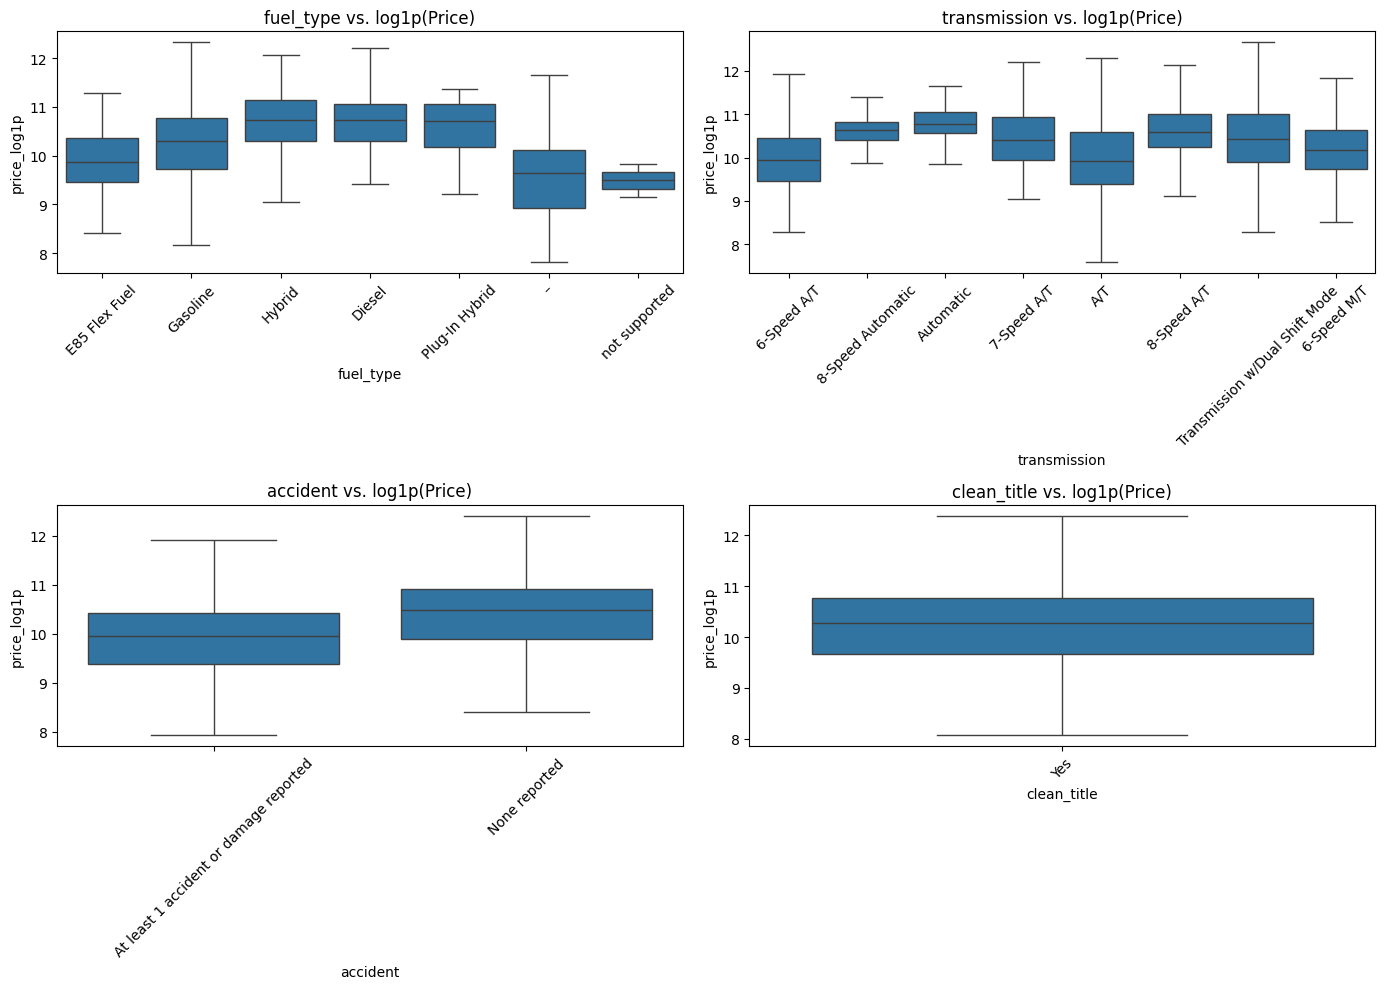

In [59]:
# Categorical Feature vs. Price (safe for raw string price values)
price_numeric = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
 )

plt.figure(figsize=(14, 10))
for i, feature in enumerate(['fuel_type', 'transmission', 'accident', 'clean_title'], start=1):
    plt.subplot(2, 2, i)

    feature_clean = df[feature].astype(str).str.strip().replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown', '-': 'Unknown'})
    top_vals = feature_clean.value_counts().head(8).index
    mask = feature_clean.isin(top_vals) & price_numeric.notna() & (price_numeric >= 0)

    sub = pd.DataFrame({
        feature: feature_clean[mask],
        'price_log1p': np.log1p(price_numeric[mask])
    })

    sns.boxplot(data=sub, x=feature, y='price_log1p', showfliers=False)
    plt.title(f'{feature} vs. log1p(Price)')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


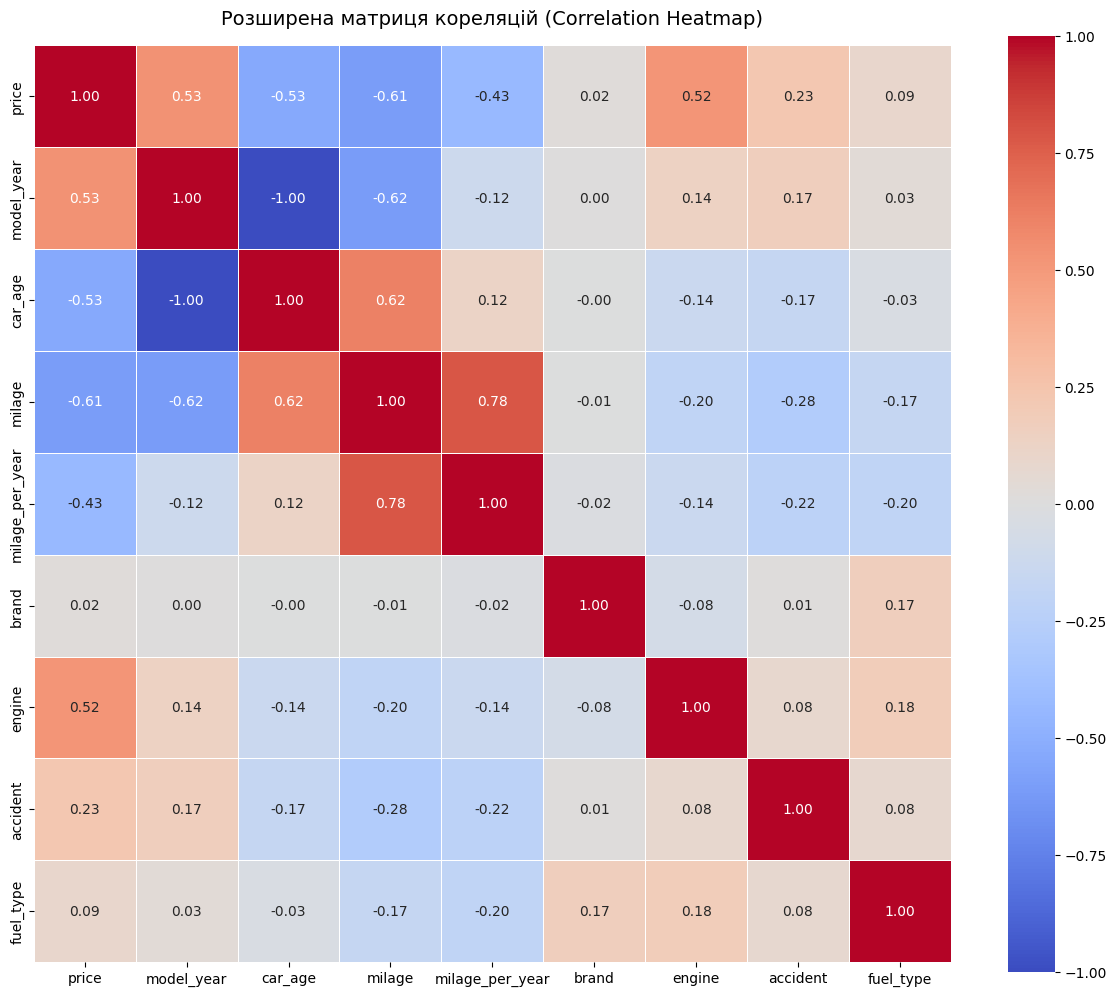

In [ ]:
correlation_features = [
    'price',             # Наш таргет (обов'язково на першому або останньому місці для зручності)
    'model_year',        # Рік випуску
    'car_age',           # Вік авто
    'milage',            # Загальний пробіг
    'milage_per_year',   # Пробіг за рік (наша нова фіча)
    'brand',             # Бренд (вже у вигляді цифр після LabelEncoder)
    'engine',            # Двигун
    'accident',          # Наявність ДТП
    'fuel_type'          # Тип пального
]

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix, 
    annot=True,     
    fmt=".2f",        
    cmap='coolwarm',     
    vmin=-1, vmax=1,     
    linewidths=0.5,  
    square=True         
)

plt.title('Розширена матриця кореляцій (Correlation Heatmap)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
def parse_milage(value):
    if pd.isna(value):
        return np.nan
    digits = re.sub(r'[^0-9]', '', str(value))
    return float(digits) if digits else np.nan

def parse_price(value):
    if pd.isna(value):
        return np.nan
    cleaned = re.sub(r'[^0-9.]', '', str(value))
    if cleaned.count('.') > 1:
        return np.nan
    return float(cleaned) if cleaned else np.nan

categorical_columns = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown', '-': 'Unknown'})

df['milage'] = df['milage'].apply(parse_milage)
df['price'] = df['price'].apply(parse_price)
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')

current_year = pd.Timestamp.now().year
df['car_age'] = (current_year - df['model_year']).clip(lower=0)

# ФІЛЬТРАЦІЯ АНОМАЛІЙ (Відкидаємо "шум")
print(f"Розмір до фільтрації: {df.shape}")
df = df.dropna(subset=['price']).copy()
df = df[(df['price'] >= 1000) & (df['price'] <= 150000)] 
df = df[(df['milage'] <= 400000)] 
print(f"Розмір після видалення екстремальних викидів: {df.shape}")

for col in ['milage', 'model_year', 'car_age']:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown').astype(str)

print("Дані очищено! Пропусків залишилось:\n", df.isnull().sum().sum())

Розмір до фільтрації: (4009, 13)
Розмір після видалення екстремальних викидів: (3890, 13)
Дані очищено! Пропусків залишилось:
 0


In [ ]:
brand_model_map = df.groupby('brand')['model'].apply(lambda x: sorted(list(x.astype(str).unique()))).to_dict()
unique_brands = sorted(df['brand'].astype(str).unique().tolist())
print(f'Створено карту Бренд -> Модель для {len(unique_brands)} брендів.')

# Label Encoding
label_encoders_dict = {}
for column in categorical_columns:
    le = LabelEncoder()
    le.fit(df[column])
    label_encoders_dict[column] = le
    df[column] = le.transform(df[column])

# Feature engineering
numerical_columns = ['model_year', 'milage', 'car_age']
df['milage_per_year'] = df['milage'] / (df['car_age'] + 1)

for column in numerical_columns:
    df[f'{column}_squared'] = df[column] ** 2

df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in numerical_columns + ['milage_per_year']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Scaling числових ознак
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# РОЗДІЛЕННЯ ТА ЛОГАРИФМУВАННЯ ТАРГЕТУ
X = df.drop(['price'], axis=1)
# Логарифмуємо ціну, щоб зменшити вплив "хвоста" дорогих авто
y = np.log1p(df['price']) 
feature_columns_list = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Дані підготовлено для навчання. Кількість фіч: {len(feature_columns_list)}')

Створено карту Бренд -> Модель для 56 брендів.
Дані підготовлено для навчання. Кількість фіч: 16


Початок тренування моделей. Будь ласка, зачекайте...

Тренування Lasso (Linear)...
Тренування Ridge (Linear)...
Тренування Gradient Boosting...
Тренування Random Forest...


,Model,R-squared,RMSE ($),MAE ($)
0,Random Forest,0.7940,12393.25,7687.41
1,Gradient Boosting,0.7875,12587.15,7646.30
2,Ridge (Linear),0.6469,16224.42,9802.07
3,Lasso (Linear),0.6277,16659.03,9985.42


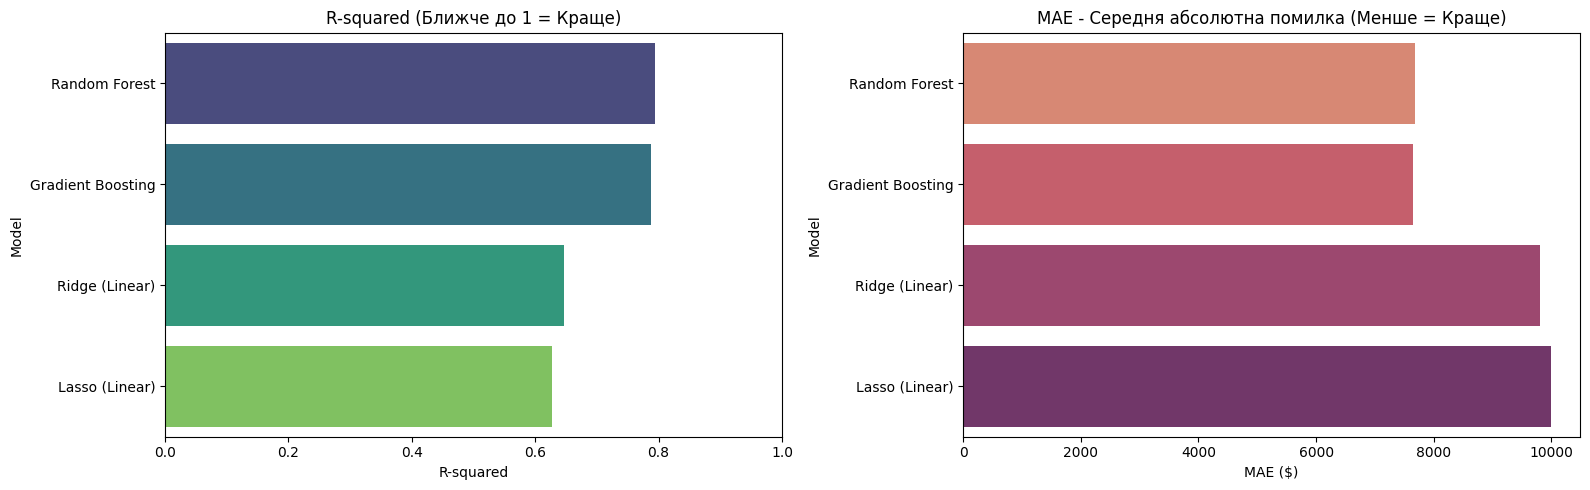

In [ ]:
# Ініціалізація моделей
models = {
    "Lasso (Linear)": Lasso(alpha=0.01, random_state=42), # Зменшили alpha, бо таргет тепер логарифмований
    "Ridge (Linear)": Ridge(alpha=1.0, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
trained_models = {}

print("Початок тренування моделей. Будь ласка, зачекайте...\n")

for name, model in models.items():
    print(f"Тренування {name}...")
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    # Повертаємо ціни в реальні долари для чесної оцінки (експонента мінус 1)
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)
    
    results.append({
        "Model": name,
        "R-squared": round(r2, 4),
        "RMSE ($)": round(rmse, 2),
        "MAE ($)": round(mae, 2) # Середня помилка в доларах
    })
    trained_models[name] = model

# Створення DataFrame з результатами
results_df = pd.DataFrame(results).sort_values(by="R-squared", ascending=False).reset_index(drop=True)
display(results_df)

# Візуалізація результатів
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x='R-squared', y='Model', data=results_df, palette='viridis', ax=axes[0])
axes[0].set_title('R-squared (Ближче до 1 = Краще)')
axes[0].set_xlim(0, 1)

sns.barplot(x='MAE ($)', y='Model', data=results_df, palette='flare', ax=axes[1])
axes[1].set_title('MAE - Середня абсолютна помилка (Менше = Краще)')

plt.tight_layout()
plt.show()

In [ ]:
# Автоматично обираємо найкращу модель за R2
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n🏆 Найкращою моделлю визнана: {best_model_name}. Зберігаємо її для додатку.")

saved_objects = {
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "label_encoders": label_encoders_dict,
    "categorical_columns": categorical_columns,
    "numerical_columns": numerical_columns,
    "feature_columns": feature_columns_list,
    "unique_brands": unique_brands,
    "brand_model_map": brand_model_map
}

save_dir = "models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Створено директорію {save_dir}")

save_path = os.path.join(save_dir, "car_price_model.pkl")
with open(save_path, "wb") as f:
    pickle.dump(saved_objects, f)

print(f"\nУСПІХ! Модель {best_model_name} та всі артефакти збережено у {save_path}!")


🏆 Найкращою моделлю визнана: Random Forest. Зберігаємо її для додатку.
ВАЖЛИВО ДЛЯ БЕКЕНДУ: Модель повертає логарифм ціни. Для виводу на екран використовуйте np.expm1(prediction).

УСПІХ! Модель Random Forest та всі артефакти збережено у models\car_price_model.pkl!
